In [1]:
!pip install yfinance

In [20]:
import yfinance as yf
data = yf.download("AAPL", period="5y", interval="1d")
data.head()

/tmp/ipykernel_657/2392211884.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="5y", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-09-07,152.830933,153.386887,150.587576,151.153293,82278300
2021-09-08,151.289825,153.172285,150.187651,153.113765,74420200
2021-09-09,150.275421,152.265171,150.158366,151.660446,57305700
2021-09-10,145.301041,151.650701,145.037686,151.182527,140893200
2021-09-13,145.866760,147.690700,145.086460,146.920163,102404300


In [9]:
data.to_csv("AAPL_stock_data.csv")

In [11]:
print(data.shape)

(1254, 5)


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-09-07 to 2026-09-03
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1253 non-null   float64
 1   (High, AAPL)    1253 non-null   float64
 2   (Low, AAPL)     1253 non-null   float64
 3   (Open, AAPL)    1253 non-null   float64
 4   (Volume, AAPL)  1254 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [13]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1253.000000,1253.000000,1253.000000,1253.000000,1.254000e+03
mean,199.811611,201.807671,197.615369,199.592557,6.422655e+07
std,49.176510,49.560645,48.702456,49.083873,2.868158e+07
min,122.827606,125.529381,121.992521,123.800259,1.791060e+07
25%,161.710526,163.029343,159.876363,161.356890,4.515302e+07
50%,187.503998,188.849800,186.194773,187.494147,5.581925e+07
75%,231.599274,233.646910,228.769811,231.493517,7.606822e+07
max,339.786926,344.273097,337.059318,339.736982,3.186799e+08


In [14]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-09-07,152.830902,153.386856,150.587546,151.153263,82278300
2021-09-08,151.289825,153.172285,150.187651,153.113765,74420200
2021-09-09,150.275452,152.265202,150.158397,151.660477,57305700
2021-09-10,145.301010,151.650670,145.037656,151.182496,140893200
2021-09-13,145.866745,147.690684,145.086445,146.920148,102404300


In [15]:
data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,1
High,AAPL,1
Low,AAPL,1
Open,AAPL,1
Volume,AAPL,0


In [16]:
data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,1
High,AAPL,1
Low,AAPL,1
Open,AAPL,1
Volume,AAPL,0


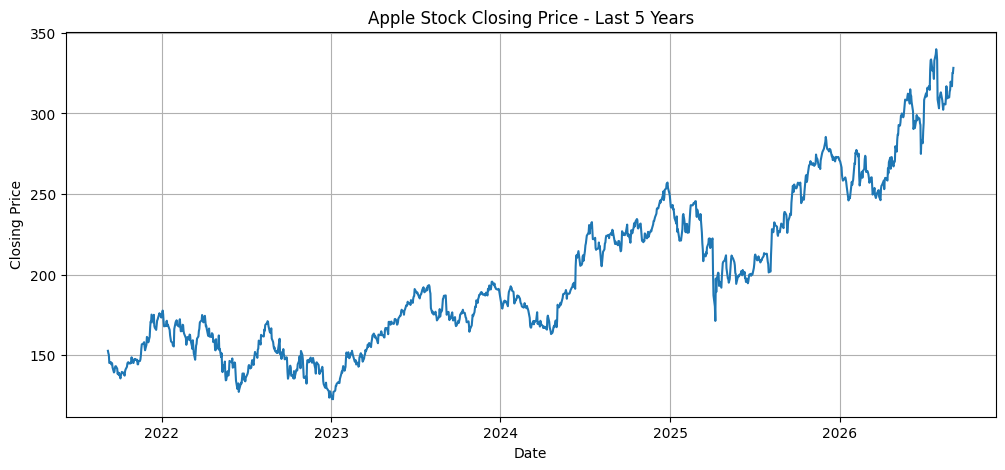

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(data.index, data["Close"])
plt.title("Apple Stock Closing Price - Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [22]:
df = data[["Close"]].copy()

df["Previous_Close"] = df["Close"].shift(1)

df = df.dropna()

df.head()

Price,Close,Previous_Close
Ticker,AAPL,
Date,,
2021-09-08,151.289825,152.830933
2021-09-09,150.275421,151.289825
2021-09-10,145.301041,150.275421
2021-09-13,145.866760,145.301041
2021-09-14,144.471970,145.866760


In [23]:
X = df[["Previous_Close"]]
y = df["Close"]

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (1253, 1)
Y shape: (1253, 1)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 1002
Testing data: 251


In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [26]:
predictions = model.predict(X_test)

print("First 10 predictions:")
print(predictions[:10])

First 10 predictions:
[[238.76022827]
 [238.67091009]
 [236.87446854]
 [233.37090362]
 [225.86747722]
 [229.08322054]
 [233.09299275]
 [235.70329986]
 [237.14243828]
 [237.97617091]]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 3.148504409037142
Root Mean Squared Error: 4.475142795187346
R² Score: 0.968543016224265


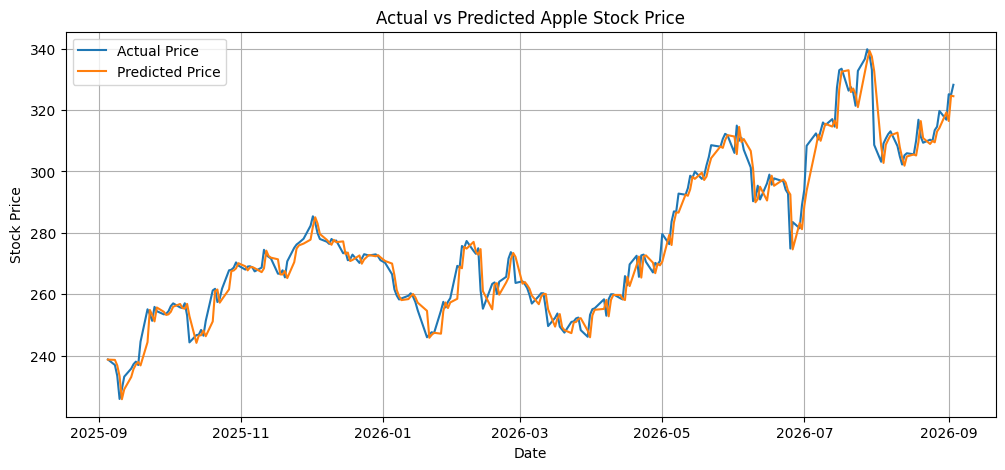

In [28]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test.values, label="Actual Price")
plt.plot(y_test.index, predictions, label="Predicted Price")

plt.title("Actual vs Predicted Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)
plt.show()

In [29]:
previous_price = float(input("Enter previous closing price: "))

predicted_price = model.predict([[previous_price]])

print("Predicted next closing price:", predicted_price[0])

Enter previous closing price: 200
Predicted next closing price: [200.01129276]


In [30]:
df.to_csv("AAPL_processed_data.csv")

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
